## Imports

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "big_data_g2" / "data"
#print(DATA_DIR)

## Helper Functions

In [2]:
# helper function to load json
def load_lookup(path):
    with open(path) as f:
        raw = json.load(f)
    df_lu = pd.DataFrame(raw) 
    return dict(zip(df_lu["id"], df_lu["name"]))

def check_duplicates(df, exclude=None, mappings=None):
    cols = [c for c in df.columns if c not in (exclude or [])]
    rows = []
    for col in cols:
        series = df[col]
        if mappings and col in mappings:
            series = series.map(mappings[col])
        dupes = series.duplicated(keep=False).sum()
        rows.append({"column": col, "duplicate_count": dupes, "duplicate_%": round(100 * dupes / len(df), 1)})
    return pd.DataFrame(rows).set_index("column").sort_values("duplicate_count", ascending=False)

## Data Loading
Load the four DBLP shards, pair files (train/val/test), and JSON lookup tables.

In [3]:
dblp_1_path = DATA_DIR / "dblp-1.csv"
dblp_2_path = DATA_DIR / "dblp-2.csv"
dblp_3_path = DATA_DIR / "dblp-3.csv"
dblp_4_path = DATA_DIR / "dblp-4.csv"

dblp_1 = pd.read_csv(dblp_1_path, index_col=0)
dblp_2 = pd.read_csv(dblp_2_path, index_col=0)
dblp_3 = pd.read_csv(dblp_3_path, index_col=0)
dblp_4 = pd.read_csv(dblp_4_path, index_col=0)

print(dblp_1.shape)
print(dblp_2.shape)
print(dblp_3.shape)
print(dblp_4.shape)

(4279, 15)
(4301, 15)
(4329, 15)
(4256, 15)


In [4]:
all_match = dblp_1.columns.equals(dblp_2.columns) and \
            dblp_2.columns.equals(dblp_3.columns) and \
            dblp_3.columns.equals(dblp_4.columns)

print(all_match)

True


The structure of columns match all `dblp` files. Hence, we concat those `.csv` files

In [5]:
df = pd.concat([dblp_1, dblp_2, dblp_3, dblp_4], ignore_index=True)

In [6]:
# df holds original columns only; all derived/computed columns go here
df_extra = pd.DataFrame(index=df.index)

In [7]:
ptype        = load_lookup(DATA_DIR / "ptype.json")
pjournal     = load_lookup(DATA_DIR / "pjournal.json")
pjournalfull = load_lookup(DATA_DIR / "pjournalfull.json")
pbooktitle   = load_lookup(DATA_DIR / "pbooktitle.json")
pbooktitlefull = load_lookup(DATA_DIR / "pbooktitlefull.json")

id_mappings = {
    "ptype_id":          ptype,
    "pjournal_id":       pjournal,
    "pbooktitle_id":     pbooktitle,
    "pjournalfull_id":   pjournalfull,
    "pbooktitlefull_id": pbooktitlefull,
}

for name, m in [("ptype", ptype), ("pjournal", pjournal),
                ("pjournalfull", pjournalfull), ("pbooktitle", pbooktitle),
                ("pbooktitlefull", pbooktitlefull)]:
    print(f"{name}: {len(m)} rows")

ptype: 9 rows
pjournal: 718 rows
pjournalfull: 90 rows
pbooktitle: 2720 rows
pbooktitlefull: 1084 rows


## Basic Statistics 
Get a quick overview of dtypes, non-null counts, numeric summaries, and a random sample.

In [8]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17165 entries, 0 to 17164
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pauthor            17165 non-null  object 
 1   peditor            0 non-null      float64
 2   ptitle             17165 non-null  object 
 3   pyear              17165 non-null  int64  
 4   paddress           0 non-null      float64
 5   ppublisher         17 non-null     object 
 6   pseries            5 non-null      object 
 7   pid                17165 non-null  int64  
 8   pkey               17165 non-null  object 
 9   ptype_id           17165 non-null  int64  
 10  pjournal_id        17165 non-null  int64  
 11  pbooktitle_id      17165 non-null  int64  
 12  pjournalfull_id    17165 non-null  int64  
 13  pbooktitlefull_id  17165 non-null  int64  
 14  partition          17165 non-null  int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 7.2 MB


In [9]:
df.sample(5, random_state=42)

,pauthor,peditor,ptitle,pyear,paddress,ppublisher,pseries,pid,pkey,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
3706,Frank Suits|Michael Pitman|Jed W. Pitera|Willi...,NaN,Overview of molecular dynamics techniques and ...,-2005,NaN,NaN,NaN,2002783,journals/ibmrd/SuitsPPSG05,3,0,5,0,5,1
2518,Yong Liu|David J. Hill 0002|Alejandro Rodrígue...,NaN,Near-real-time precipitation virtual sensor us...,2008,NaN,NaN,NaN,273337,conf/gis/LiuHRMKFMM08,2,0,5,0,5,1
5843,Yan Song|Guo-Jun Qi|Xian-Sheng Hua|Li-Rong Dai...,NaN,Video Annotation by Active Learning and Semi-S...,2006,NaN,NaN,NaN,388674,conf/icmcs/SongQHDW06,2,0,0,0,0,2
11843,Yiyang Pei|Ying-Chang Liang|Kah Chan Teh|Kwok ...,NaN,How much time is needed for wideband spectrum ...,2009,NaN,NaN,NaN,2354661,journals/twc/PeiLTL09,0,162,5,162,5,3
11847,Hajime Ohyanagi|Tsuyoshi Tanaka|Hiroaki Sakai|...,NaN,The Rice Annotation Project Database (RAP-DB):...,2006,NaN,NaN,NaN,2159200,journals/nar/OhyanagiTSSYHFANIIIGS06,3,45,5,45,5,3


In [10]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].describe()

,peditor,pyear,paddress,pid,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
count,0.0,17165.000000,0.0,1.716500e+04,17165.000000,17165.000000,17165.000000,17165.000000,17165.000000,17165.000000
mean,NaN,359.046140,NaN,1.062491e+06,1.815264,64.476959,486.942208,64.476959,486.942208,2.498806
std,NaN,1971.505007,NaN,8.352665e+05,1.256148,137.321095,695.529516,137.321095,695.529516,1.115588
min,NaN,-2011.000000,NaN,1.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,-2004.000000,NaN,3.568410e+05,1.000000,0.000000,5.000000,0.000000,5.000000,2.000000
50%,NaN,1999.000000,NaN,7.230580e+05,2.000000,0.000000,68.000000,0.000000,68.000000,3.000000
75%,NaN,2007.000000,NaN,2.013849e+06,3.000000,45.000000,794.000000,45.000000,794.000000,3.000000
max,NaN,2011.000000,NaN,2.434225e+06,8.000000,717.000000,2719.000000,717.000000,2719.000000,4.000000


## Missing Values: `paddress`, `ppublisher`, `pseries`, `peditor`
List NaN counts, empty strings, and total missing rate per column.

In [11]:
is_null = df.isnull()
is_empty = df.astype(str).eq("") & ~is_null
is_missing = is_null | is_empty

missing = pd.DataFrame(
    {
    "null_count" : is_null.sum(),
    "empty_str" : is_empty.sum(),
    "total_missing" : is_missing.sum(),
    "missing_pct" : is_missing.mean().mul(100).round(1)
    }
).sort_values("missing_pct", ascending=False)

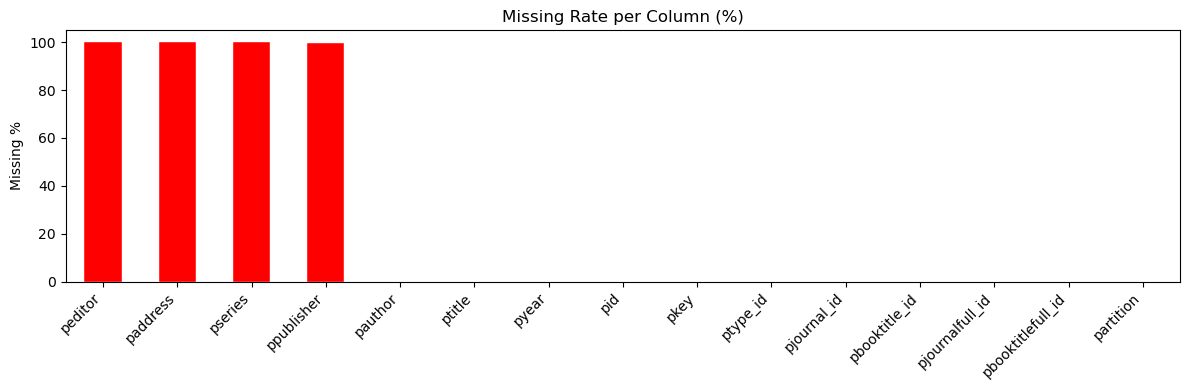

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

missing["missing_pct"].plot(kind="bar", ax=ax, color='red',edgecolor="white", linewidth=0.3)

ax.set_title("Missing Rate per Column (%)")
ax.set_ylabel("Missing %")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Non-Mising Str Columns: `pauthor`, `ptitle`
Inspect title and author length distributions, detect outliers, and audit whitespace/NaN patterns.

Since `pkey` stores a different format string than `ptitle` or `pauthor`, we only look at character distributions of the latter two.

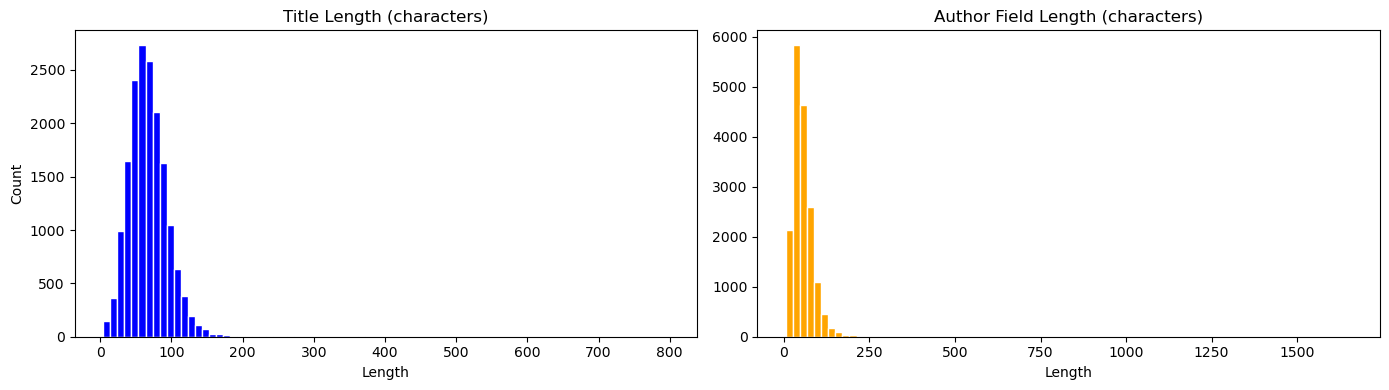

In [13]:
df_extra["title_len"]  = df["ptitle"].str.len()
df_extra["author_len"] = df["pauthor"].str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(df_extra["title_len"], bins=80, color="blue", edgecolor="white")
ax1.set_title("Title Length (characters)")
ax1.set_xlabel("Length")
ax1.set_ylabel("Count")

ax2.hist(df_extra["author_len"].dropna(), bins=80, edgecolor="white", color="orange")
ax2.set_title("Author Field Length (characters)")
ax2.set_xlabel("Length")
plt.tight_layout()
plt.show()

Outliers of `ptitle` column

In [14]:
short_titles = df[df_extra["title_len"] < 10][["ptitle", "pkey"]].join(df_extra["title_len"])
long_titles  = df[df_extra["title_len"] > 300][["ptitle", "pkey"]].join(df_extra["title_len"])
print(f"Titles shorter than 10 chars: {len(short_titles)}")
display(short_titles.head(10))
print(f"\nTitles longer than 300 chars: {len(long_titles)}")
display(long_titles.head(10))

Titles shorter than 10 chars: 35


,ptitle,pkey,title_len
1035,J. Smit,conf/eurosam/Smit79,7
1996,Preface.,journals/tcs/HofmannRP99,8
2100,Modulus.,reference/crypt/Contini05c,8
2172,Preface.,journals/entcs/HappeB10,8
4111,Preface.,journals/speech/CutlerCL10,8
4211,CAD.,conf/dagstuhl/RollerH93,4
4227,Preface.,journals/eswa/AlvaradoCC04,8
4234,News.,journals/ieeesp/StoneAA04,5
4280,Z. Sun,conf/prozess/Sun88,6
5265,J. Y. Kim,conf/premi/Kim05,9



Titles longer than 300 chars: 13


,ptitle,pkey,title_len
506,Luc Moreau|Simon Miles|Carole A. Goble|R. Mark...,conf/ccgrid/MoreauMGGDAACRFGGGLLLLMOPPRRRRSSSW...,446
2218,Donna Karolchik|Robert M. Kuhn|Robert Baertsch...,journals/nar/KarolchikKBBCDGHHHKMPPRRRSSTTWZHK08,367
2221,Paul Flicek|B. L. Aken|Kathryn Beal|Benoit Bal...,journals/nar/FlicekABBCCCCCCDDEFFGHHHHHJJKKKKL...,799
5095,Francesco Pappalardo|Mark D. Halling-Brown|Nic...,journals/bib/PappalardoHRZAEPDPPMCRSMCBLBMLBB09,363
7033,Peter Fankhauser|Norbert Fuhr|Jens Hartmann|An...,conf/gi/FankhauserFHJKKKKL0MOOPRRSBSSSSSVWW05,390
8570,Robert M. Kuhn|Donna Karolchik|Ann S. Zweig|He...,journals/nar/KuhnKZTTTSSSSRRRPPHHHDCBBBHK07,381
9669,Gabriele Garzoglio|Ian Alderman|Mine Altunay|R...,journals/grid/GarzoglioAAABCCDFFGHHKJLMPSSSSSVW09,365
10028,Kieron Messer|Josef Kittler|Mohammad Sadeghi|S...,conf/avbpa/MesserKSMMBCSCVSPKKPKTADM03,302
10294,Piotr D. Adamczyk|Kevin Hamilton|Alan Chamberl...,journals/dsonline/AdamczykHCBTOHLSKLSKNAMARPL07,302
10876,John H. Edmondson|Paul I. Rubinfeld|Peter J. B...,journals/dtj/EdmondsonRBBBCCDDFJMMPRSTW95,326


We notice that oftentimes titles contain author names. For long outliers, authors are separated by `|`. Lets see whether this is the case in `pauthor`.

In [15]:
long_auhtors = df[df_extra["author_len"] > 200][["pauthor", "pkey"]].join(df_extra["author_len"])
print(f"Author inputs longer than 200 chars: {len(long_auhtors)}")
display(long_auhtors.head(10))

Author inputs longer than 200 chars: 83


,pauthor,pkey,author_len
29,Matthias Fuchs|Christoph Borst|Paolo Robuffo G...,conf/icra/FuchsBGBKLGSPKBSWH09,208
208,Ion-Florin Talos|Lauren O'Donnell|Carl-Fredrik...,conf/miccai/TalosOWWWYPGMMRGBJK03,253
266,Robert L. Melcher|Paul M. Alt|Derek B. Dove|Th...,journals/ibmrd/MelcherADCCDEHLNOPRSSSTUY98,305
402,Sabine Lehmann|Stephan Oepen|Sylvie Regnier-Pr...,journals/corr/cmp-lg-9607018,205
437,Michael Bedford Taylor|Jason Sungtae Kim|Jason...,journals/micro/TaylorKMWGGHJLLMSSSSFAA02,267
670,Leming M. Shi|Weida Tong|Hong Fang|Uwe Scherf|...,journals/bmcbi/ShiTFSHPFGGSHFXPHXPCC05,247
1055,Alessandro Bozzon|Marco Brambilla|Piero Frater...,conf/sigir/BozzonBFNDMNPAPLZBWC09,235
1070,Pedro Santos|André Stork|Thomas Gierlinger|Ala...,conf/hci/SantosSGPAJBJPWCABPHM07,236
1714,N. Brook|A. Bogdanchikov|A. Buckley|Joel Closi...,journals/corr/cs-DC-0306060,455
1825,Periklis Andritsos|Ronald Fagin|Ariel Fuxman|L...,journals/debu/AndritsosFFHHHKMNPVVY02,215


Lets look into author counts distribution:

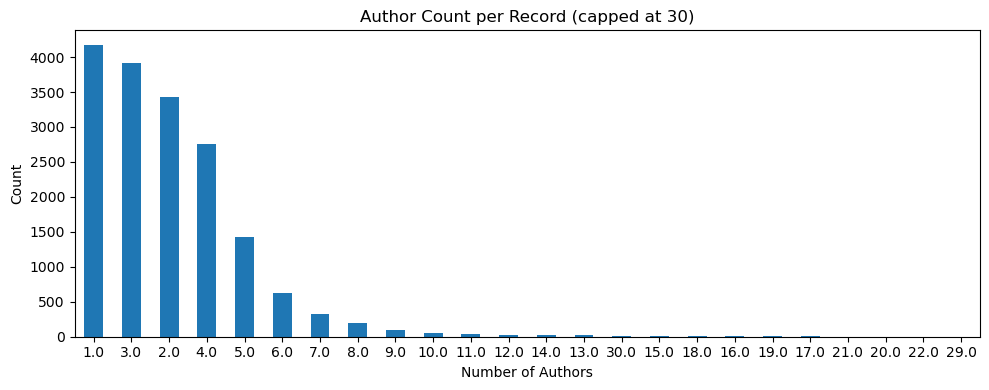

In [16]:
df_extra["author_count"] = df["pauthor"].str.count(r"\|") + 1
df_extra.loc[df["pauthor"].isnull(), "author_count"] = np.nan

fig, ax = plt.subplots(figsize=(10, 4))
# since distribution has a long tail, lets look into top 30
df_extra["author_count"].dropna().clip(upper=30).value_counts().plot(kind="bar", ax=ax)
ax.set_title("Author Count per Record (capped at 30)")
ax.set_xlabel("Number of Authors")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Publication Type: `ptype_id`
We examine raw `ptype_id` frequencies and detect duplicate names.

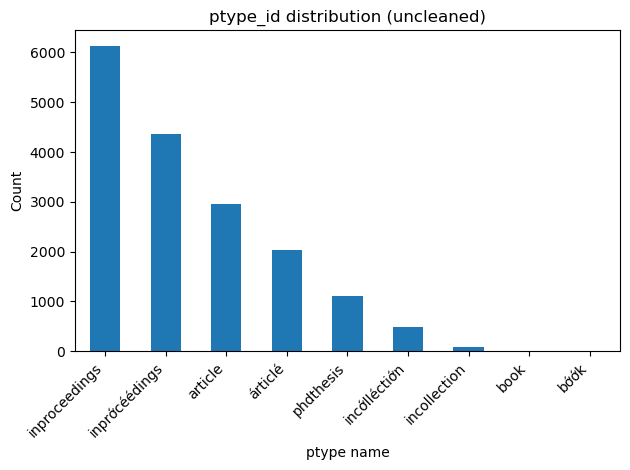

In [17]:
ptype_counts = df["ptype_id"].value_counts(dropna=False)
ptype_named  = ptype_counts.rename(index=ptype)

fig, ax = plt.subplots()
ptype_named.plot(kind="bar", ax=ax)
ax.set_title("ptype_id distribution (uncleaned)")
ax.set_xlabel("ptype name")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
print("All ptype.json entries:")
for id_, name in sorted(ptype.items()):
    print(f"  id={id_:2d}  name={repr(name)}")

All ptype.json entries:
  id= 0  name='árticlé'
  id= 1  name='inproceedings'
  id= 2  name='inprớcéédings'
  id= 3  name='article'
  id= 4  name='phdthesis'
  id= 5  name='incớlléctiớn'
  id= 6  name='incollection'
  id= 7  name='bớớk'
  id= 8  name='book'


## `pkey` Structure Analysis
We parse the `pkey` field to extract prefixes and conference names

In [19]:
df_extra["pkey_prefix"]     = df["pkey"].str.split("/").str[0]
df_extra["pkey_conference"] = df["pkey"].str.split("/").str[1]

In [20]:
print(df_extra["pkey_prefix"].value_counts())

pkey_prefix
conf         10954
journals      6082
series          47
reference       42
books           28
tr              11
phd              1
Name: count, dtype: int64


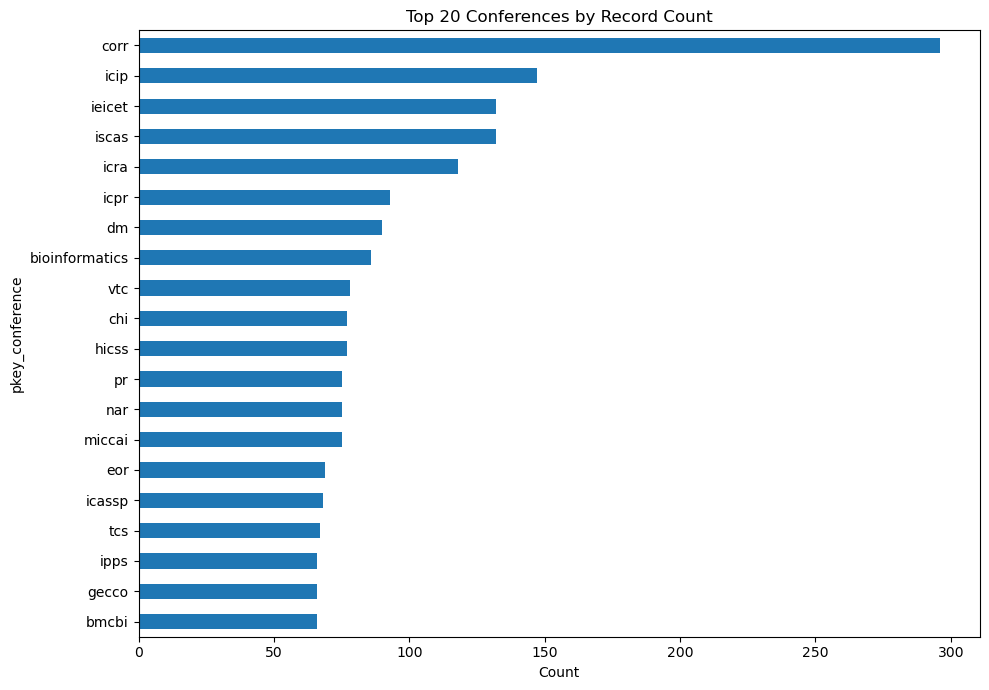

In [21]:
top_conference = df_extra["pkey_conference"].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top_conference.plot(kind="barh", ax=ax)
ax.set_title("Top 20 Conferences by Record Count")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

In [22]:
# 6b — Cross-tabulate pkey_prefix vs ptype_canonical
crosstab = pd.crosstab(
    df_extra["pkey_prefix"],
    df["ptype_id"].map(ptype)
)
print("pkey_prefix vs ptype_canonical:")
display(crosstab)

pkey_prefix vs ptype_canonical:


ptype_id,article,book,bớớk,incollection,incớlléctiớn,inproceedings,inprớcéédings,phdthesis,árticlé
pkey_prefix,,,,,,,,,
books,0,4,0,17,4,0,3,0,0
conf,0,0,2,3,123,6014,3215,1107,490
journals,2944,1,0,0,351,123,1129,1,1533
phd,0,0,0,0,0,0,0,1,0
reference,0,0,0,29,6,0,5,0,2
series,0,2,2,30,7,0,5,0,1
tr,8,0,0,0,0,1,1,0,1


## Year Distribution `pyear`
Identify and quantify negative `pyear` values, visualise raw vs corrected distributions.

In [23]:
n_neg = (df["pyear"] < 0).sum()
n_pos = (df["pyear"] >= 0).sum()
print(f"Negative pyear values: {n_neg} ({100*n_neg/len(df):.1f}%)")
print(f"Non-negative pyear values: {n_pos}")
print("\nNegative year value_counts:")
print(df.loc[df["pyear"] < 0, "pyear"].value_counts().head(20))

Negative pyear values: 7045 (41.0%)
Non-negative pyear values: 10120

Negative year value_counts:
pyear
-2009    833
-2008    782
-2007    703
-2010    639
-2006    632
-2005    593
-2004    469
-2003    407
-2002    278
-2001    208
-2000    200
-1999    174
-1997    156
-1998    133
-1996    111
-1994     91
-1993     90
-1995     88
-1992     69
-1990     55
Name: count, dtype: int64


`pyear` distribution

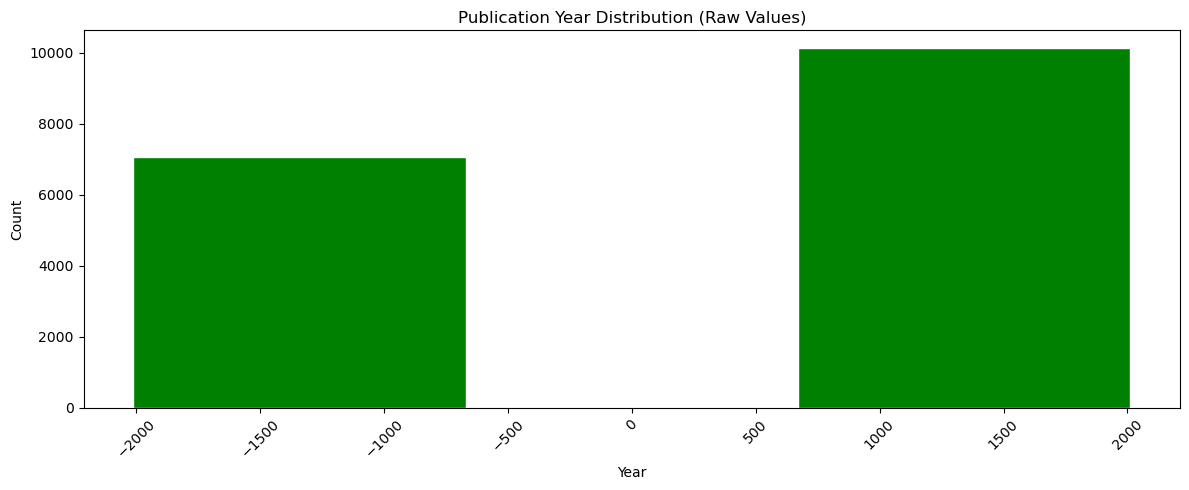

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df["pyear"].dropna(), bins=3, edgecolor="white", color="green")
ax.set_title("Publication Year Distribution (Raw Values)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lets convert `pyear` into absolute values

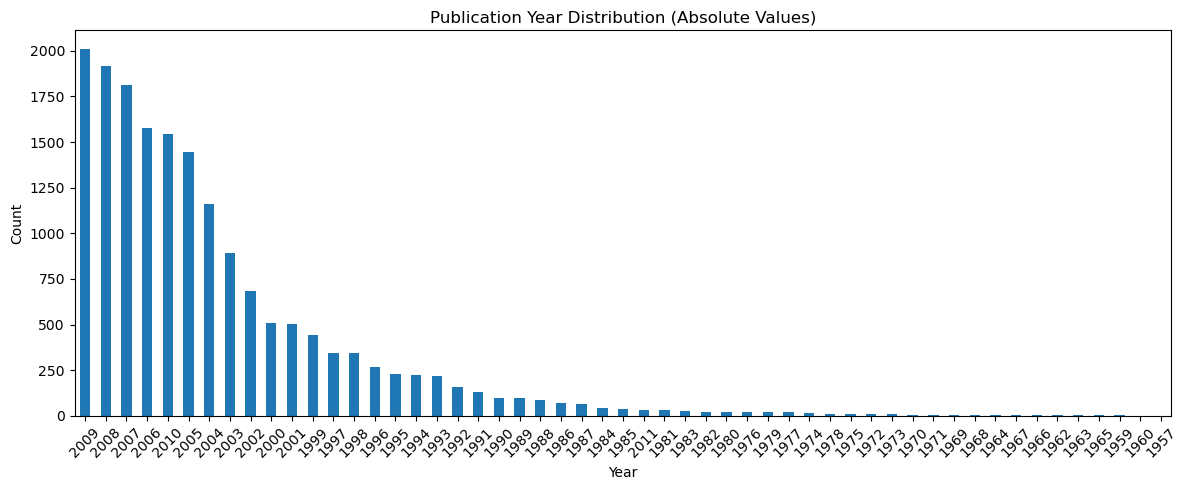

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
df["pyear"].abs().value_counts(dropna=False).plot(kind="bar", ax=ax)
ax.set_title("Publication Year Distribution (Absolute Values)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Journal & Booktitle Distributions: `pjournal_id` & `pbooktitle_id`
Resolve integer IDs to human-readable names and inspect top values.

<Axes: ylabel='pjournal_id'>

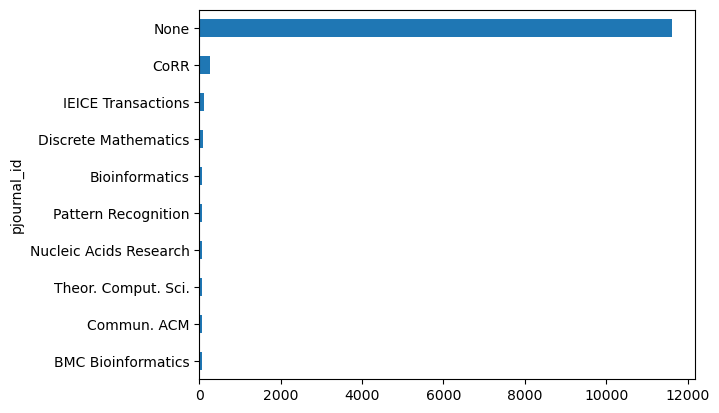

In [26]:
df["pjournal_id"].map(pjournal).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

<Axes: ylabel='pbooktitle_id'>

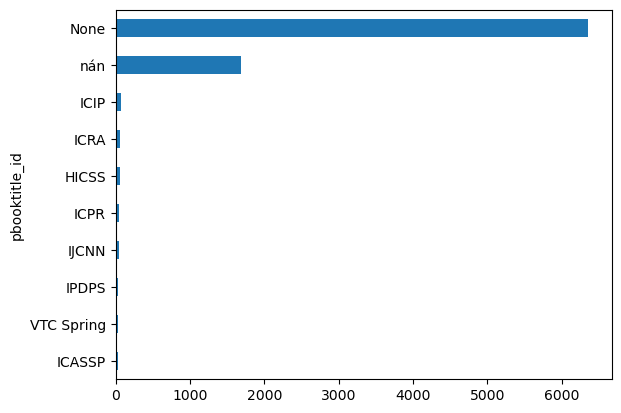

In [27]:
df["pbooktitle_id"].map(pbooktitle).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

## Journal Full & Booktitle Full Distributions: `pjournalfull_id` & `pbooktitlefull_id`

<Axes: ylabel='pjournalfull_id'>

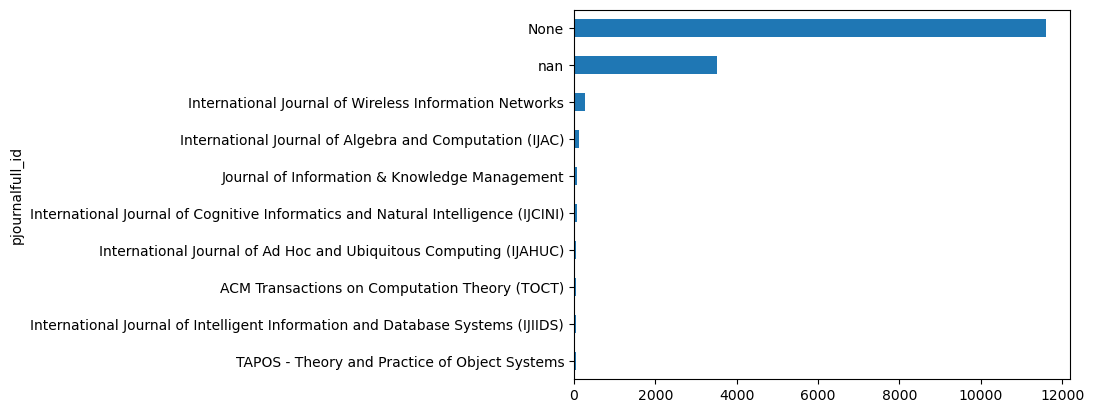

In [28]:
df["pjournalfull_id"].map(pjournalfull).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

<Axes: ylabel='pbooktitlefull_id'>

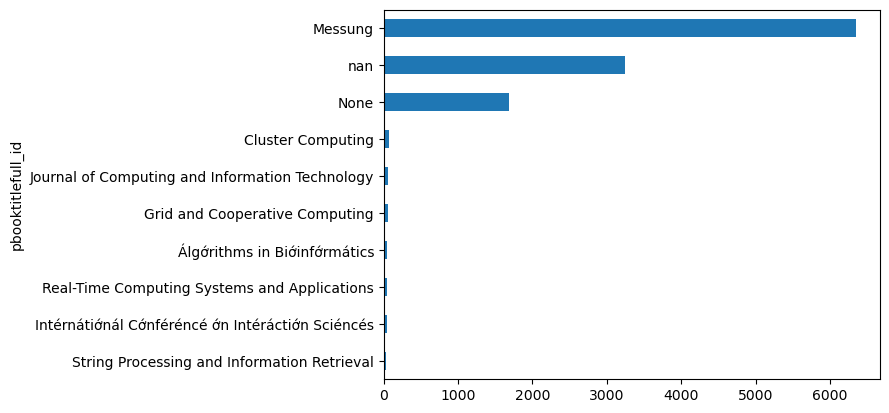

In [29]:
df["pbooktitlefull_id"].map(pbooktitlefull).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

## Duplicate Detection in Raw Records
Check for exact row duplicates and field-level uniqueness issues.

In [30]:
# 11a — Exact row duplicates
n_full_dups = df.duplicated().sum()
print(f"Exact row duplicates: {n_full_dups}")

Exact row duplicates: 0


In [31]:
display(check_duplicates(df, exclude=["peditor", "paddress"], mappings=id_mappings))

,duplicate_count,duplicate_%
column,,
ptype_id,17165,100.0
partition,17165,100.0
pjournalfull_id,17162,100.0
ppublisher,17161,100.0
pseries,17160,100.0
pyear,17153,99.9
pjournal_id,17014,99.1
pbooktitlefull_id,17007,99.1
pbooktitle_id,16209,94.4


# Data Cleaning — to do
## Empty Columns
- **`peditor`, `paddress`** — drop entirely (100% NaN, no signal)
- **`ppublisher`, `pseries`** — drop or encode as binary presence flag (>99.9% missing)

## Text Columns
- **`ptitle`** — x records contain author lists instead of titles; inspect and fix or flag
- **`ptitle`** — x amount normalised duplicate titles (e.g. "Preface.", "Editorial."); decide whether to keep or deduplicate
- **`pauthor`** — 9.1% of records share an identical author string; verify whether these are true duplicates or legitimate shared authorship

### Numeric Columns
- **`pyear`** — take absolute value (`df["pyear"].abs()`); 41% of records have negative years

In [32]:
df["pyear"] = df["pyear"].abs()
df.head(3)

,pauthor,peditor,ptitle,pyear,paddress,ppublisher,pseries,pid,pkey,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
0,Jorge Semião|Juan J. Rodríguez-Andina|Fabian V...,NaN,Improving the Tolerance of Pipeline Based Circ...,2007,NaN,NaN,NaN,180843,conf/dft/SemiaoRVSTT07,1,0,4,0,4,1
1,Patrice Caire,NaN,A Normative Multi-Agent Systems Approach to th...,2007,NaN,NaN,NaN,162991,conf/dagstuhl/Caire07,2,0,7,0,7,1
2,Sundeep B|Andrew Thangaraj,NaN,Self-Orthogonality of q-Ary Images of qm-Ary C...,2007,NaN,NaN,NaN,2261406,journals/tit/BT07,0,2,9,2,9,1


### Categorical / ID Columns
- **`ptype_id`** — remap corrupted IDs to canonical ones: `{0→3, 2→1, 5→6, 7→8}`

In [33]:
df['ptype_id'] = [3 if ptype_id == 0 else ptype_id for ptype_id in df['ptype_id']]
df['ptype_id'] = [1 if ptype_id == 2 else ptype_id for ptype_id in df['ptype_id']]
df['ptype_id'] = [6 if ptype_id == 5 else ptype_id for ptype_id in df['ptype_id']]
df['ptype_id'] = [8 if ptype_id == 7 else ptype_id for ptype_id in df['ptype_id']]

In [34]:
df['ptype_id'].value_counts()

ptype_id
1    10496
3     4979
4     1109
6      570
8       11
Name: count, dtype: int64

- **`pbooktitle_full` / `pbooktitle_id`** — treat nan as None (?) (OR SHOULD THIS BE TREATED AT NaN??) 


In [35]:
# pbooktitle_id has id=0 as nan, which will be treated as None (id=5)
df['pbooktitle_id'] = [5 if pbooktitle_id == 0 else pbooktitle_id for pbooktitle_id in df['pbooktitle_id']]
# pbooktitlefull_id has id=4 as nan, which will be treated as None (id=0)
df['pbooktitlefull_id'] = [0 if id == 4 else id for id in df['pbooktitlefull_id']]

### Cleaning Str names from the (JSON) dicts

In [41]:
import unicodedata
def clean_string(s):
    if s is None:
        return s

    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c))

    s = s.replace("-", " ")
    return s.strip().lower()


In [42]:
import re
def extract_abbreviations(name):
    if not name:
        return None

    # Extracting ABBREV in 'Full Title (ABBREV)'
    match = re.search(r'\(([^)]+)\)$', name.strip())
    if match:
        return match.group(1).strip()
   
   # Extracting ABBREV in'Full Title - ABBREV'
    match = re.search(r'\s[-–]\s([A-Z][^\s].*)$', name.strip())
    if match:
        return match.group(1).strip()
    
    return None

In [43]:
def clean_journal_titles(name):

    if not name:
        return name
    
    # remove abbreviations and acronyms 
    match = re.search(r'\(([^)]+)\)$', name.strip())
    if match:
        name = name.replace(match.group(0), "")
    
    match = re.search(r'\s[-–]\s([A-Z][^\s].*)$', name.strip())
    if match:
        name = name.replace(match.group(0), "")

    # then cleaning string normally
    cleaned = clean_string(name)
    return cleaned


In [37]:
pbooktitlefull_clean = {}

for id, name in pbooktitlefull.items():
    pbooktitlefull_clean[id] = clean_string(name)


#### Extracting Abbreviations and cleaning
- **`pjournalfull_id` / `pbooktitlefull_id`** — fall back to short name (`pjournal` / `pbooktitle`) when full name is missing (88% / 29% unmapped)

- pjournalfull has entries like this 'ACM Transactions on Sensor Networks (TOSN)' but not all entries have the abbreviations, some have it like this: 'Revista de Informática Teórica e Aplicada - RITA', and others only have the full title
- pjournal has just the abbreviations RITA', 'TOSN', but some look different, for example: Theor. Comput. Sci.'

In [39]:
# creating a dict of abbreviations to add to the df and cross check if it matches with pjournal names
abbreviations = {k: extract_abbreviations(name) for k, name in pjournalfull.items()}
df["pjournal_id"].map(abbreviations).value_counts(dropna=False).head(10).sort_values()

pjournal_id
IJDAR                                       45
IJACI                                       53
IJIIDS                                      61
Theory and Practice of Object Systems       61
TOCT                                        61
IJAHUC                                      63
IJCINI                                      76
IJAC                                       115
NaN                                       3518
None                                     12620
Name: count, dtype: int64

In [44]:
# cleaning pjournalfull names to remove abbreviations and weird stuff
pjournalfull_clean = {}

for id, name in pjournalfull.items():
    pjournalfull_clean[id] = clean_journal_titles(name)

pjournalfull_clean

{0: None,
 1: 'wirtschaftsinformatik',
 2: 'international journal of ambient computing and intelligence',
 3: 'mobile networks and applications',
 4: 'acm transactions on multimedia computing',
 5: 'international journal of wireless information networks',
 6: 'international transactions on systems science and applications',
 7: 'kunstliche intelligenz',
 8: 'international journal of bioinformatics research and applications',
 9: 'international journal of high performance computing and networking',
 10: 'journal of computers',
 11: 'international journal of advanced media and communication',
 12: 'acm transactions on computation theory',
 13: 'journal of convergence information technology',
 14: 'international journal of manufacturing research',
 15: 'journal of advanced computational intelligence and intelligent informatics',
 16: 'international journal of pattern recognition and artificial intelligence',
 17: 'journal of digital content technology and its applications',
 18: 'internat

In [45]:
pbooktitle_clean = {}

for id, name in pbooktitle.items():
    pbooktitle_clean[id] = clean_string(name)

## TODO
- In the pbooktitle_clean / pbooktitle there are some abbreviations that are either duplicate or they have the same acronym - we should decide how to handle that too
- I created a dict called "abbreviations" which I think we can use to check if the ID in the df for pjournalfull match the correct ID of the acronym/abbreviation in the pjournal

# Save df as new clean CSV 
(TODO eventually)

In [51]:
import json

#turning pbooktitle, pbooktitlefull, pjournal (# TODO), pjournalfull into new clean json files

with open('clean_data/pjournalfull_clean.json', 'w', encoding='utf-8') as f:
    json.dump(pjournalfull_clean, f, ensure_ascii=False, indent=2)

with open('clean_data/pbooktitle_clean.json', 'w', encoding='utf-8') as f:
    json.dump(pbooktitle_clean, f, ensure_ascii=False, indent=2)

with open('clean_data/pbooktitlefull_clean.json', 'w', encoding='utf-8') as f:
    json.dump(pbooktitlefull_clean, f, ensure_ascii=False, indent=2)

In [ ]:
#df.to_csv("dblp_cleaned.csv", index=False)

# Side by side (figure/plots) comparison of EDA done with the clean data 
(TODO eventually)